In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
import matplotlib.ticker as ticker
from adjustText import adjust_text
import copy
import statistics
import pandas as pd
from itertools import chain
import sqlite3
import json
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
c=299792458

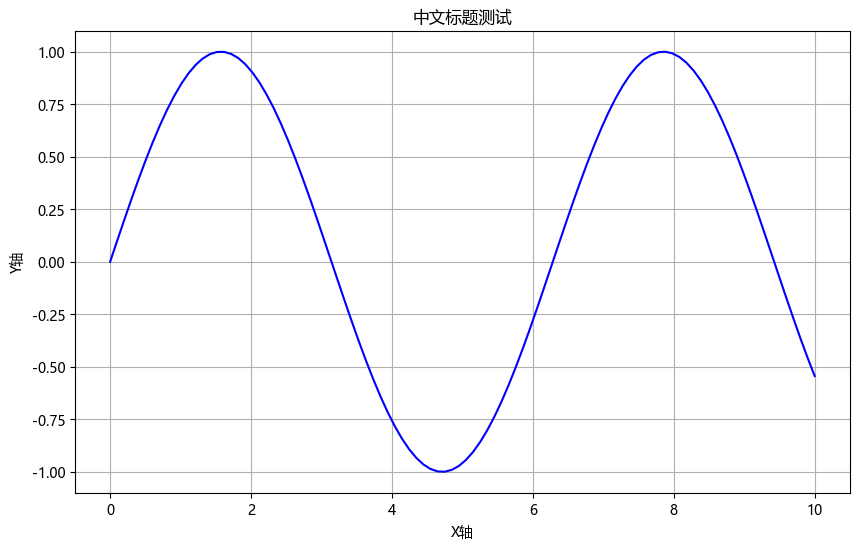

In [2]:
# 设置中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False


x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-')
plt.title('中文标题测试')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.grid(True)
plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import seaborn as sns
from collections import Counter


In [4]:
class SpectraDatabase:
    def __init__(self, db_path="spectra_data.db"):
        """初始化数据库连接"""
        self.db_path = db_path
        self.conn = None
        
    def connect(self):
        """连接数据库"""
        self.conn = sqlite3.connect(self.db_path)
        return self.conn
    
    def create_tables(self):
        """创建数据表"""
        conn = self.connect()
        cursor = conn.cursor()
        
        # 主表：光谱元数据
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS spectra_metadata (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                source TEXT, 
                molecule_name TEXT,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
            )
        ''')
        
        # 光谱数据表
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS spectra_data (
                spectrum_id INTEGER,
                velocity BLOB,  -- 存储速度数组
                flux BLOB,   -- 存储强度数组
                units TEXT,
                data_points INTEGER,
                FOREIGN KEY (spectrum_id) REFERENCES spectra_metadata(id),
                PRIMARY KEY (spectrum_id)
            )
        ''')
        
        # 标签索引表（便于搜索）
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS spectrum_tags (
                spectrum_id INTEGER,
                molecule_name TEXT
            )
        ''')
        
        conn.commit()
        print("数据库表创建完成！")
    
    def add_spectrum(self, metadata, velocity, flux):
        """添加一条光谱数据"""
        conn = self.connect()
        cursor = conn.cursor()
        
        # 插入元数据
        cursor.execute('''
            INSERT INTO spectra_metadata 
            (source, molecule_name)
            VALUES (?, ?)
        ''', (
            metadata.get('source'),
            metadata.get('molecule_name')
        ))
        
        spectrum_id = cursor.lastrowid
        
        # 插入光谱数据（将numpy数组转为二进制）
        cursor.execute('''
            INSERT INTO spectra_data 
            (spectrum_id, velocity, flux, units, data_points)
            VALUES (?, ?, ?, ?, ?)
        ''', (
            spectrum_id,
            velocity.tobytes(),  # numpy数组转二进制
            flux.tobytes(),
            metadata.get('units', 'km/s'),
            len(velocity)
        ))
        
        conn.commit()
        return spectrum_id
    
    def get_spectrum(self, spectrum_id):
        """获取完整的光谱数据"""
        conn = self.connect()
        cursor = conn.cursor()
        
        # 获取元数据
        cursor.execute('''
            SELECT * FROM spectra_metadata WHERE id = ?
        ''', (spectrum_id,))
        metadata_row = cursor.fetchone()
        
        # 获取元数据的列名
        metadata_columns = [desc[0] for desc in cursor.description]
        metadata = dict(zip(metadata_columns, metadata_row))
        
        # 获取光谱数据
        cursor.execute('''
            SELECT velocity, flux, units FROM spectra_data 
            WHERE spectrum_id = ?
        ''', (spectrum_id,))
        data_row = cursor.fetchone()
        
        if not metadata_row or not data_row:
            return None
        
        # 将二进制转回numpy数组
        velocity = np.frombuffer(data_row[0], dtype=np.float64)
        flux = np.frombuffer(data_row[1], dtype=np.float64)
        
        
        return {
            'metadata': metadata,
            'velocity': velocity,
            'flux': flux,
            'units': data_row[2]
        }
    
    def search_by_molecule(self, molecule_name):
        """按分子名称搜索"""
        conn = self.connect()
        cursor = conn.cursor()
        
        cursor.execute('''
            SELECT id, molecule_name,source
            FROM spectra_metadata 
            WHERE molecule_name LIKE ? 
            ORDER BY molecule_name
        ''', (f'%{molecule_name}%',))
        
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        return [dict(zip(columns, row)) for row in results]
    
    def get_all_metadata(self):
        """获取所有光谱的元数据（不包含光谱数据本身）"""
        conn = self.connect()
        cursor = conn.cursor()
        
        cursor.execute('''
            SELECT id, source, molecule_name, created_at
            FROM spectra_metadata
            ORDER BY molecule_name
        ''')
        
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        return [dict(zip(columns, row)) for row in results]
    
    def close(self):
        """关闭数据库连接"""
        if self.conn:
            self.conn.close()

In [5]:
class SpectraVisualizer:
    """光谱可视化工具"""
    
    def __init__(self, db):
        self.db = db
        
    def plot_single_spectrum(self, spectrum_id, show_peaks=True, 
                           save_path=None, figsize=(12, 6)):
        """绘制单个光谱"""
        
        # 从数据库获取数据
        spectrum = self.db.get_spectrum(spectrum_id)
        
        if spectrum is None:
            print(f"未找到光谱 ID: {spectrum_id}")
            return
        
        velocity = spectrum['velocity']
        flux = spectrum['flux']
        metadata = spectrum['metadata']
        
        # 创建图形
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                      gridspec_kw={'height_ratios': [3, 1]})
        
        # 主图：光谱
        ax1.plot(velocity, flux, 'b-', linewidth=1.5, alpha=0.8, 
                label='原始数据')
        
        # 标记峰值
        if show_peaks:
            peaks = self._find_peaks(flux)
            if len(peaks) > 0:
                ax1.scatter(velocity[peaks], flux[peaks], 
                          color='red', s=50, marker='o', 
                          label=f'峰值 ({len(peaks)}个)', zorder=5)
        
        # 设置主图属性
        title = f"{metadata.get('molecule_name', '未知分子')} 光谱 (ID: {spectrum_id})"
        if metadata.get('source'):
            title += f" | 来源: {metadata['source']}"
        
        ax1.set_title(title, fontsize=14, fontweight='bold')
        ax1.set_ylabel("流量", fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='best')
        
        # 子图：残差（去除基线后）
        baseline = self._estimate_baseline(flux)
        residual = flux - baseline
        ax2.plot(velocity, residual, 'g-', linewidth=1, alpha=0.7)
        ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel(f"速度 ({spectrum.get('units', 'km/s')})", fontsize=12)
        ax2.set_ylabel("残差", fontsize=12)
        ax2.grid(True, alpha=0.3)
        
        # 添加统计信息
        stats_text = (f"数据点数: {len(velocity)}\n"
                     f"速度范围: {velocity[0]:.2f} 到 {velocity[-1]:.2f}\n"
                     f"流量范围: {flux.min():.3e} 到 {flux.max():.3e}\n"
                     f"信噪比: {flux.max()/np.std(flux):.1f}" 
                     if np.std(flux) > 0 else "信噪比: N/A")
        
        ax1.text(0.02, 0.98, stats_text,
                transform=ax1.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_multiple_spectra(self, spectrum_ids, normalize=False, 
                            save_path=None, figsize=(14, 8)):
        """绘制多个光谱（叠加显示）"""
        
        fig, ax = plt.subplots(figsize=figsize)
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(spectrum_ids)))
        
        for idx, spectrum_id in enumerate(spectrum_ids):
            spectrum = self.db.get_spectrum(spectrum_id)
            
            if spectrum is None:
                print(f"未找到光谱 ID: {spectrum_id}")
                continue
            
            velocity = spectrum['velocity']
            flux = spectrum['flux']
            metadata = spectrum['metadata']
            
            # 归一化处理
            if normalize:
                flux = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
            
            # 绘制
            label = f"{metadata.get('molecule_name', '未知')} (ID: {spectrum_id})"
            ax.plot(velocity, flux, color=colors[idx], linewidth=1.5, 
                   alpha=0.7, label=label)
        
        ax.set_xlabel(f"速度 (km/s)", fontsize=12)
        ax.set_ylabel("流量" + (" (归一化)" if normalize else ""), fontsize=12)
        ax.set_title(f"多个光谱比较 (共 {len(spectrum_ids)} 个)", 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_by_molecule(self, molecule_name, max_spectra=10, 
                        save_path=None, figsize=(15, 10)):
        """绘制特定分子的多个光谱"""
        
        # 搜索该分子的所有光谱
        results = self.db.search_by_molecule(molecule_name)
        
        if not results:
            print(f"未找到分子 {molecule_name} 的光谱")
            return
        
        print(f"找到 {len(results)} 个 {molecule_name} 光谱")
        
        # 限制显示数量
        display_count = min(len(results), max_spectra)
        spectrum_ids = [r['id'] for r in results[:display_count]]
        
        # 创建图形
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        axes = axes.flatten()
        
        # 1. 所有光谱叠加
        for i, spectrum_id in enumerate(spectrum_ids):
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                velocity = spectrum['velocity']
                flux = spectrum['flux']
                flux_norm = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
                axes[0].plot(velocity, flux_norm, linewidth=1, alpha=0.6)
        
        axes[0].set_title(f"{molecule_name} 光谱 (所有叠加)")
        axes[0].set_xlabel("速度 (km/s)")
        axes[0].set_ylabel("归一化流量")
        axes[0].grid(True, alpha=0.3)
        
        # 2. 平均光谱
        all_fluxes = []
        for spectrum_id in spectrum_ids:
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                flux = spectrum['flux']
                flux_norm = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
                all_fluxes.append(flux_norm)
        
        if all_fluxes:
            avg_flux = np.mean(all_fluxes, axis=0)
            std_flux = np.std(all_fluxes, axis=0)
            
            axes[1].plot(velocity, avg_flux, 'b-', linewidth=2, label='平均')
            axes[1].fill_between(velocity, avg_flux - std_flux, avg_flux + std_flux, 
                               alpha=0.3, color='blue', label='标准差')
            axes[1].set_title(f"{molecule_name} 平均光谱")
            axes[1].set_xlabel("速度 (km/s)")
            axes[1].set_ylabel("归一化流量")
            axes[1].grid(True, alpha=0.3)
            axes[1].legend()
        
        # 3. 最大值光谱
        max_spectrum_id = spectrum_ids[0]
        max_amplitude = 0
        for spectrum_id in spectrum_ids:
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                flux = spectrum['flux']
                if np.max(flux) > max_amplitude:
                    max_amplitude = np.max(flux)
                    max_spectrum_id = spectrum_id
        
        spectrum = self.db.get_spectrum(max_spectrum_id)
        if spectrum:
            axes[2].plot(spectrum['velocity'], spectrum['flux'], 'r-', linewidth=2)
            axes[2].set_title(f"{molecule_name} 最强光谱 (ID: {max_spectrum_id})")
            axes[2].set_xlabel("速度 (km/s)")
            axes[2].set_ylabel("流量")
            axes[2].grid(True, alpha=0.3)
        
        # 4. 信噪比分布
        snr_values = []
        for spectrum_id in spectrum_ids:
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                flux = spectrum['flux']
                snr = flux.max() / np.std(flux) if np.std(flux) > 0 else 0
                snr_values.append(snr)
        
        axes[3].hist(snr_values, bins=10, alpha=0.7, color='green', edgecolor='black')
        axes[3].set_title(f"{molecule_name} 信噪比分布")
        axes[3].set_xlabel("信噪比")
        axes[3].set_ylabel("光谱数量")
        axes[3].grid(True, alpha=0.3)
        
        plt.suptitle(f"{molecule_name} 分子光谱分析", fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_database_summary(self, save_path=None, figsize=(16, 12)):
        """绘制数据库整体概览"""
        
        # 获取所有光谱的元数据
        all_spectra = self.db.get_all_metadata()
        
        if not all_spectra:
            print("数据库为空")
            return
        
        print(f"数据库中有 {len(all_spectra)} 条光谱")
        
        # 创建图形
        fig = plt.figure(figsize=figsize)
        gs = GridSpec(3, 3, figure=fig)
        
        # 1. 分子分布 (条形图)
        ax1 = fig.add_subplot(gs[0, 0])
        molecules = [s.get('molecule_name', '未知') for s in all_spectra]
        mol_counter = Counter(molecules)
        
        mol_names, mol_counts = zip(*mol_counter.most_common(10))  # 显示前10个
        bars = ax1.bar(range(len(mol_names)), mol_counts, alpha=0.7, color='skyblue')
        ax1.set_title("分子分布 (前10)", fontsize=12, fontweight='bold')
        ax1.set_ylabel("光谱数量", fontsize=10)
        ax1.set_xticks(range(len(mol_names)))
        ax1.set_xticklabels(mol_names, rotation=45, ha='right', fontsize=9)
        
        # 在条形上添加数量
        for bar, count in zip(bars, mol_counts):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   str(count), ha='center', va='bottom', fontsize=8)
        
        # 2. 来源分布 (饼图)
        ax2 = fig.add_subplot(gs[0, 1])
        sources = [s.get('source', '未知') for s in all_spectra]
        src_counter = Counter(sources)
        
        src_names, src_counts = zip(*src_counter.most_common(8))
        wedges, texts, autotexts = ax2.pie(src_counts, labels=src_names, autopct='%1.1f%%',
                                          startangle=90, textprops={'fontsize': 9})
        ax2.set_title("来源分布", fontsize=12, fontweight='bold')
        
        # 3. 数据点数分布
        ax3 = fig.add_subplot(gs[0, 2])
        data_points = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                data_points.append(len(spectrum['velocity']))
        
        ax3.hist(data_points, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        ax3.set_title("数据点数分布", fontsize=12, fontweight='bold')
        ax3.set_xlabel("数据点数", fontsize=10)
        ax3.set_ylabel("光谱数量", fontsize=10)
        ax3.grid(True, alpha=0.3)
        
        # 4. 信噪比分布
        ax4 = fig.add_subplot(gs[1, 0])
        snr_values = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                flux = spectrum['flux']
                snr = flux.max() / np.std(flux) if np.std(flux) > 0 else 0
                snr_values.append(snr)
        
        ax4.hist(snr_values, bins=20, alpha=0.7, color='salmon', edgecolor='black')
        ax4.set_title("信噪比分布", fontsize=12, fontweight='bold')
        ax4.set_xlabel("信噪比", fontsize=10)
        ax4.set_ylabel("光谱数量", fontsize=10)
        ax4.grid(True, alpha=0.3)
        
        # 5. 平均流量分布
        ax5 = fig.add_subplot(gs[1, 1])
        mean_flux_values = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                flux = spectrum['flux']
                mean_flux_values.append(np.mean(flux))
        
        ax5.hist(mean_flux_values, bins=20, alpha=0.7, color='gold', edgecolor='black')
        ax5.set_title("平均流量分布", fontsize=12, fontweight='bold')
        ax5.set_xlabel("平均流量", fontsize=10)
        ax5.set_ylabel("光谱数量", fontsize=10)
        ax5.grid(True, alpha=0.3)
        
        # 6. 峰值数量分布
        ax6 = fig.add_subplot(gs[1, 2])
        peak_counts = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                flux = spectrum['flux']
                peaks = self._find_peaks(flux, height=np.std(flux)*2)
                peak_counts.append(len(peaks))
        
        unique, counts = np.unique(peak_counts, return_counts=True)
        ax6.bar(unique, counts, alpha=0.7, color='purple', edgecolor='black')
        ax6.set_title("峰值数量分布", fontsize=12, fontweight='bold')
        ax6.set_xlabel("峰值数量", fontsize=10)
        ax6.set_ylabel("光谱数量", fontsize=10)
        ax6.grid(True, alpha=0.3)
        
        # 7. 随机抽样显示4个光谱
        ax7 = fig.add_subplot(gs[2, :])
        
        # 随机选择4个光谱
        import random
        sample_ids = random.sample([s['id'] for s in all_spectra], min(4, len(all_spectra)))
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(sample_ids)))
        
        for i, spectrum_id in enumerate(sample_ids):
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                velocity = spectrum['velocity']
                flux = spectrum['flux']
                flux_norm = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
                
                label = f"ID {spectrum_id}: {spectrum['metadata'].get('molecule_name', '未知')}"
                ax7.plot(velocity, flux_norm + i*0.3, color=colors[i], 
                        linewidth=1.5, label=label, alpha=0.8)
        
        ax7.set_title("随机抽样光谱 (归一化并垂直偏移)", fontsize=12, fontweight='bold')
        ax7.set_xlabel("速度 (km/s)", fontsize=10)
        ax7.set_ylabel("归一化流量 (偏移后)", fontsize=10)
        ax7.legend(loc='upper right', fontsize=9)
        ax7.grid(True, alpha=0.3)
        
        plt.suptitle(f"光谱数据库概览 (共 {len(all_spectra)} 条光谱)", 
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def _find_peaks(self, flux, height=None, distance=10):
        """寻找峰值点"""
        from scipy.signal import find_peaks
        
        if height is None:
            height = np.std(flux) * 2
        
        peaks, _ = find_peaks(flux, height=height, distance=distance)
        return peaks
    
    def _estimate_baseline(self, flux, n_baseline=5):
        """估计基线"""
        if len(flux) <= 2 * n_baseline:
            return np.mean(flux)
        
        baseline = np.mean(np.concatenate([flux[:n_baseline], flux[-n_baseline:]]))
        return baseline

In [6]:
def interactive_visualization(db):
    """交互式可视化界面"""
    
    visualizer = SpectraVisualizer(db)
    
    while True:
        print("\n" + "=" * 50)
        print("          光谱数据可视化工具")
        print("=" * 50)
        print("1. 📊 查看数据库概览")
        print("2. 📈 查看单个光谱")
        print("3. 🔍 按分子查看光谱")
        print("4. 📉 比较多个光谱")
        print("5. 🎲 随机查看光谱")
        print("6. 📋 生成报告")
        print("7. ❌ 退出")
        print("-" * 50)
        
        choice = input("请选择操作 (1-7): ")
        
        if choice == "1":
            # 数据库概览
            print("\n生成数据库概览图表...")
            save = input("是否保存图表？(输入文件名或留空): ")
            visualizer.plot_database_summary(save_path=save if save else None)
        
        elif choice == "2":
            # 单个光谱
            spectrum_id = int(input("输入光谱ID: "))
            show_peaks = input("显示峰值吗？(y/n): ").lower() == 'y'
            save = input("是否保存图表？(输入文件名或留空): ")
            
            visualizer.plot_single_spectrum(spectrum_id, show_peaks=show_peaks,
                                          save_path=save if save else None)
        
        elif choice == "3":
            # 按分子查看
            molecule = input("输入分子名 (如 CO, HCN): ")
            max_display = input("最大显示数量 (默认10): ")
            max_display = int(max_display) if max_display else 10
            
            save = input("是否保存图表？(输入文件名或留空): ")
            
            visualizer.plot_by_molecule(molecule, max_spectra=max_display,
                                      save_path=save if save else None)
        
        elif choice == "4":
            # 比较多个光谱
            print("\n输入要比较的光谱ID，用逗号分隔")
            ids_input = input("例如: 1,3,5,7\n光谱ID: ")
            
            try:
                spectrum_ids = [int(id.strip()) for id in ids_input.split(',')]
                normalize = input("归一化吗？(y/n): ").lower() == 'y'
                save = input("是否保存图表？(输入文件名或留空): ")
                
                visualizer.plot_multiple_spectra(spectrum_ids, normalize=normalize,
                                               save_path=save if save else None)
            except:
                print("输入格式错误")
        
        elif choice == "5":
            # 随机查看
            import random
            
            all_spectra = db.get_all_metadata()
            if all_spectra:
                random_id = random.choice([s['id'] for s in all_spectra])
                print(f"随机选择光谱 ID: {random_id}")
                
                spectrum = db.get_spectrum(random_id)
                if spectrum:
                    print(f"  分子: {spectrum['metadata'].get('molecule_name', '未知')}")
                    print(f"  来源: {spectrum['metadata'].get('source', '未知')}")
                    print(f"  数据点数: {len(spectrum['velocity'])}")
                
                show = input("显示这个光谱吗？(y/n): ")
                if show.lower() == 'y':
                    visualizer.plot_single_spectrum(random_id)
            else:
                print("数据库为空")
        
        elif choice == "6":
            # 生成报告
            generate_report(db, visualizer)
        
        elif choice == "7":
            print("再见！")
            break
        
        else:
            print("无效选择")
        
        input("\n按Enter键继续...")

def generate_report(db, visualizer):
    """生成可视化报告"""
    
    import os
    from datetime import datetime
    
    # 创建报告目录
    report_dir = f"spectra_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(report_dir, exist_ok=True)
    
    print(f"\n生成报告到目录: {report_dir}")
    
    # 获取所有数据
    all_spectra = db.get_all_metadata()
    
    if not all_spectra:
        print("数据库为空")
        return
    
    # 1. 数据库概览图
    print("1. 生成数据库概览图...")
    visualizer.plot_database_summary(save_path=f"{report_dir}/01_database_summary.png")
    
    # 2. 按分子统计图
    print("2. 生成分子统计图...")
    
    # 获取所有分子
    molecules = list(set([s.get('molecule_name', '未知') for s in all_spectra]))
    
    # 为每个主要分子生成图表（最多5个）
    for i, molecule in enumerate(molecules[:5]):
        print(f"  生成 {molecule} 分子图...")
        try:
            visualizer.plot_by_molecule(molecule, max_spectra=10,
                                      save_path=f"{report_dir}/02_molecule_{molecule}.png")
        except:
            print(f"  生成 {molecule} 图表时出错")
    
    # 3. 随机选择5个光谱的详细图
    print("3. 生成随机光谱详细图...")
    import random
    random_ids = random.sample([s['id'] for s in all_spectra], min(5, len(all_spectra)))
    
    for i, spectrum_id in enumerate(random_ids):
        print(f"  生成光谱 ID {spectrum_id} 图...")
        try:
            visualizer.plot_single_spectrum(spectrum_id, show_peaks=True,
                                          save_path=f"{report_dir}/03_spectrum_{spectrum_id}.png")
        except:
            print(f"  生成光谱 {spectrum_id} 图表时出错")
    
    # 4. 生成文本报告
    print("4. 生成文本报告...")
    
    with open(f"{report_dir}/report_summary.txt", 'w', encoding='utf-8') as f:
        f.write("光谱数据库分析报告\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"数据库文件: {db.db_path}\n")
        f.write(f"总光谱数量: {len(all_spectra)}\n\n")
        
        # 分子统计
        from collections import Counter
        mol_counter = Counter([s.get('molecule_name', '未知') for s in all_spectra])
        
        f.write("分子分布:\n")
        for mol, count in mol_counter.most_common():
            f.write(f"  {mol}: {count} 条 ({count/len(all_spectra)*100:.1f}%)\n")
        
        f.write("\n")
        
        # 来源统计
        src_counter = Counter([s.get('source', '未知') for s in all_spectra])
        
        f.write("来源分布:\n")
        for src, count in src_counter.most_common():
            f.write(f"  {src}: {count} 条\n")
        
        f.write("\n")
        
        # 数据统计
        data_points = []
        snr_values = []
        
        for spec in all_spectra:
            spectrum = db.get_spectrum(spec['id'])
            if spectrum:
                data_points.append(len(spectrum['velocity']))
                flux = spectrum['flux']
                snr = flux.max() / np.std(flux) if np.std(flux) > 0 else 0
                snr_values.append(snr)
        
        if data_points:
            f.write("数据统计:\n")
            f.write(f"  平均数据点数: {np.mean(data_points):.1f}\n")
            f.write(f"  最小数据点数: {np.min(data_points)}\n")
            f.write(f"  最大数据点数: {np.max(data_points)}\n")
        
        if snr_values:
            f.write(f"\n  平均信噪比: {np.mean(snr_values):.1f}\n")
            f.write(f"  最小信噪比: {np.min(snr_values):.1f}\n")
            f.write(f"  最大信噪比: {np.max(snr_values):.1f}\n")
    
    print(f"\n报告生成完成！所有文件保存在: {report_dir}")
    print(f"包含:")
    print(f"  - 数据库概览图")
    print(f"  - 分子分析图")
    print(f"  - 随机光谱详细图")
    print(f"  - 文本统计报告")

In [7]:
db = SpectraDatabase("spectra_no_noise_normalize.db")
interactive_visualization(db)


          光谱数据可视化工具
1. 📊 查看数据库概览
2. 📈 查看单个光谱
3. 🔍 按分子查看光谱
4. 📉 比较多个光谱
5. 🎲 随机查看光谱
6. 📋 生成报告
7. ❌ 退出
--------------------------------------------------
请选择操作 (1-7): 7
再见！


In [20]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE,MDS, Isomap,LocallyLinearEmbedding,SpectralEmbedding
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [9]:
# 颜色区分分子
color_map = {'33SO2':'#000000', '13CH3OH???':'#FF0000', 'CO':'#00FF00', 
             'HC15N':'#0000FF', 'CH3OH':'#FFFF00','H13CO+':'#00FFFF','SO+':'#FF00FF',
             'SiO':'#8470FF', 'SO2':'#FFC0CB', 'HCO+':'#FFA07A', 'SO':'#A9A9A9', 'CH3OCH3':'#8B0000',
             '34SO2':'#ADD8E6', 't-HCOOH':'#90EE90', 'HC3N':'#D8BFD8'}

# 形状列表
marker_map = {'Lm07':'o','Lm10': '^','Ll10': 'X','Lh03': 'p','Lh05': '*','Lh07': 'h', 'Lh08':'d','Lh09': 'D','Lh10': 'v'}

In [10]:
# 1. 连接数据库
conn = sqlite3.connect("spectra_no_noise_normalize.db")
cursor = conn.cursor()

# 2. 提取数据
cursor.execute("""
    SELECT source, molecule_name, flux 
    FROM spectra_metadata sm 
    JOIN spectra_data sd ON sm.id = sd.spectrum_id
""")

rows = cursor.fetchall()
conn.close()

if not rows:
    print("数据库中没有找到数据！")


# 3. 整理数据
sources, molecules, fluxes = zip(*rows)

# 4. 创建流量矩阵
flux_matrix = np.vstack([np.frombuffer(f, dtype=np.float64) for f in fluxes])
print(f"流量矩阵形状: {flux_matrix.shape}")

流量矩阵形状: (200, 111)


In [11]:
# 降维
spec=SpectralEmbedding(n_components=2)
digits_spec=spec.fit_transform(flux_matrix)

In [26]:
# 聚类
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(digits_spec)

D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


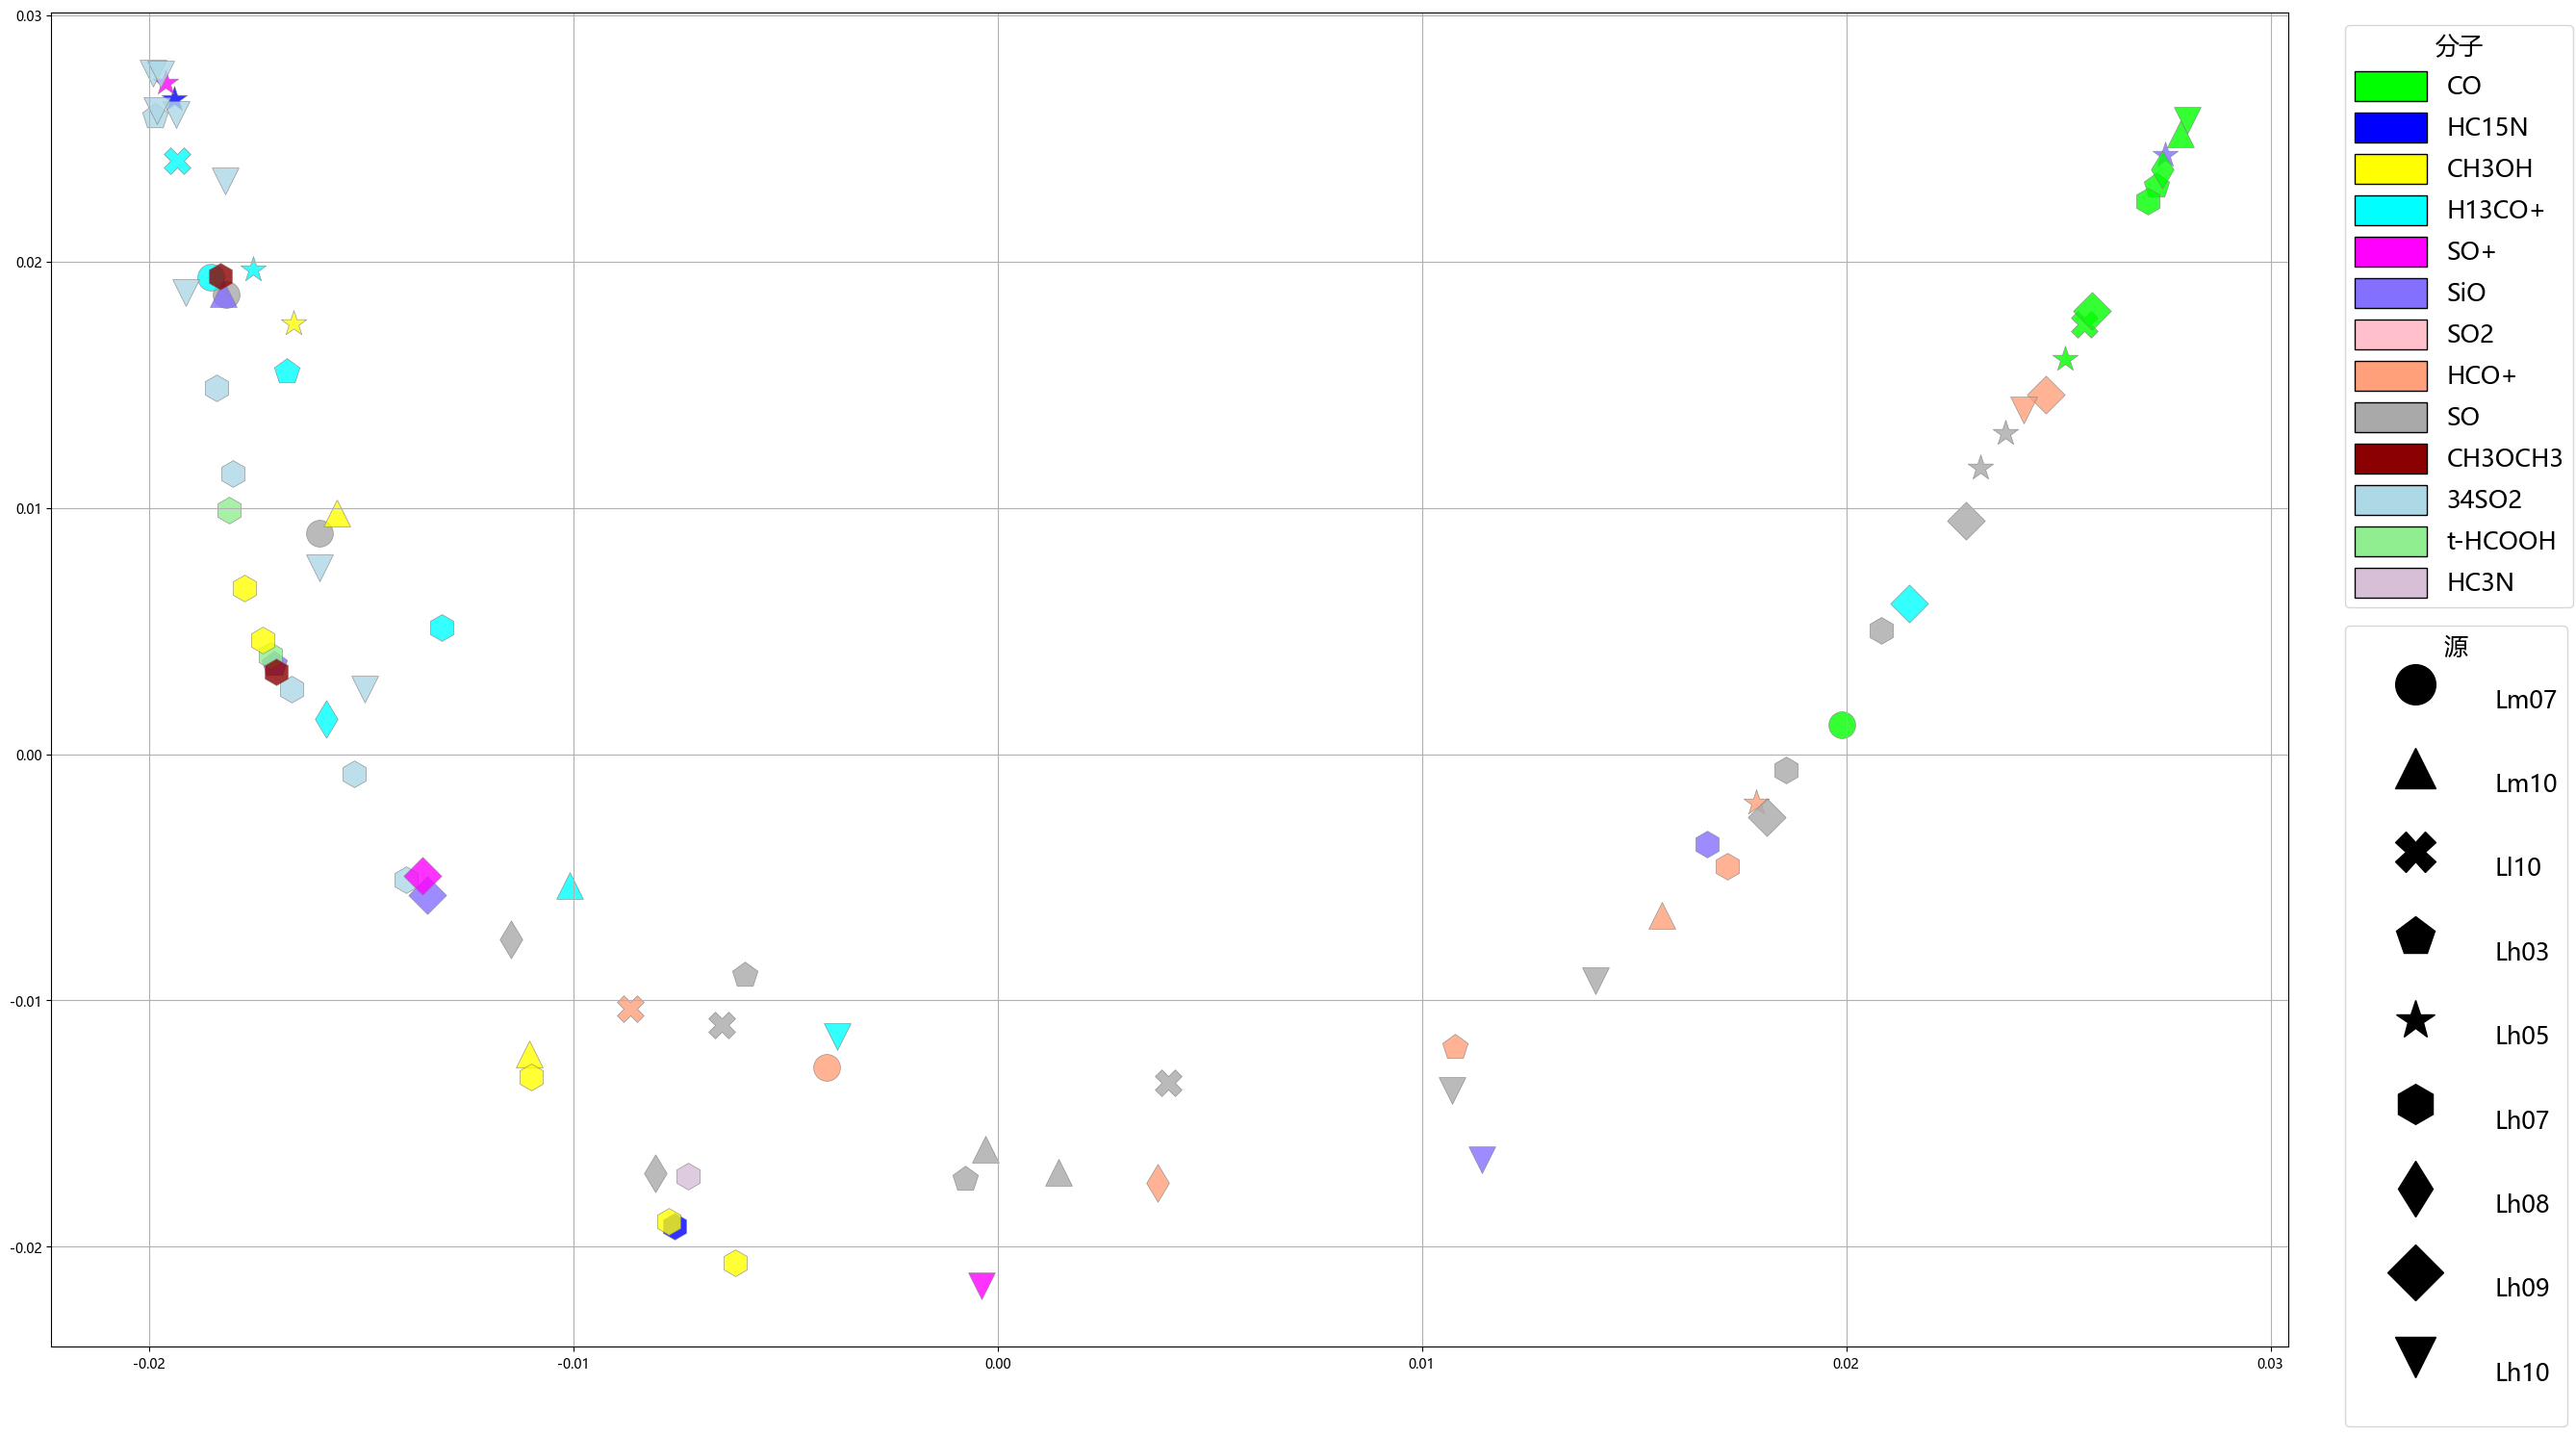

In [18]:
unique_sources = list(set(sources))
unique_molecules = list(set(molecules))

# 分子图例（颜色）
legend_elements_mol = []
for mol in color_map.keys():
    if mol in unique_molecules:
        legend_elements_mol.append(
            Patch(facecolor=color_map[mol], edgecolor='black', label=mol)
        )

# 源图例（形状）
legend_elements_src = []
for src in marker_map.keys():
    if src in unique_sources:
        # 使用Line2D创建形状图例，颜色设为黑色以便清晰显示形状
        legend_elements_src.append(
            Line2D([0], [0], marker=marker_map[src], color='w', label=src,
                   markerfacecolor='black', markersize=15, markeredgecolor='black', linewidth=0)
        )

fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()

# 绘制散点 - 修正点1：移除marker和c参数的中括号
for (x, y), src, mol in zip(digits_spec, sources, molecules):
    if mol!='SO2':
        color = color_map.get(mol) 
        marker = marker_map.get(src) 
        # 注意：这里移除了marker=[marker]和c=[color]中的中括号
        plt.scatter(x, y, c=color, marker=marker, s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)

# 添加图例 - 方法1：分别添加
legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
                    loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
                    handleheight=1.5, title_fontsize=18, fontsize=18)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_elements_src, title='源', 
                    loc='upper left', bbox_to_anchor=(1.02, 0.55), handlelength=5,
                    handleheight=5, title_fontsize=18, fontsize=18, 
                    labelspacing=0, markerscale=2.0)

# plt.tight_layout(rect=[0, 0, 0.85, 1])  # 添加布局调整
plt.show()



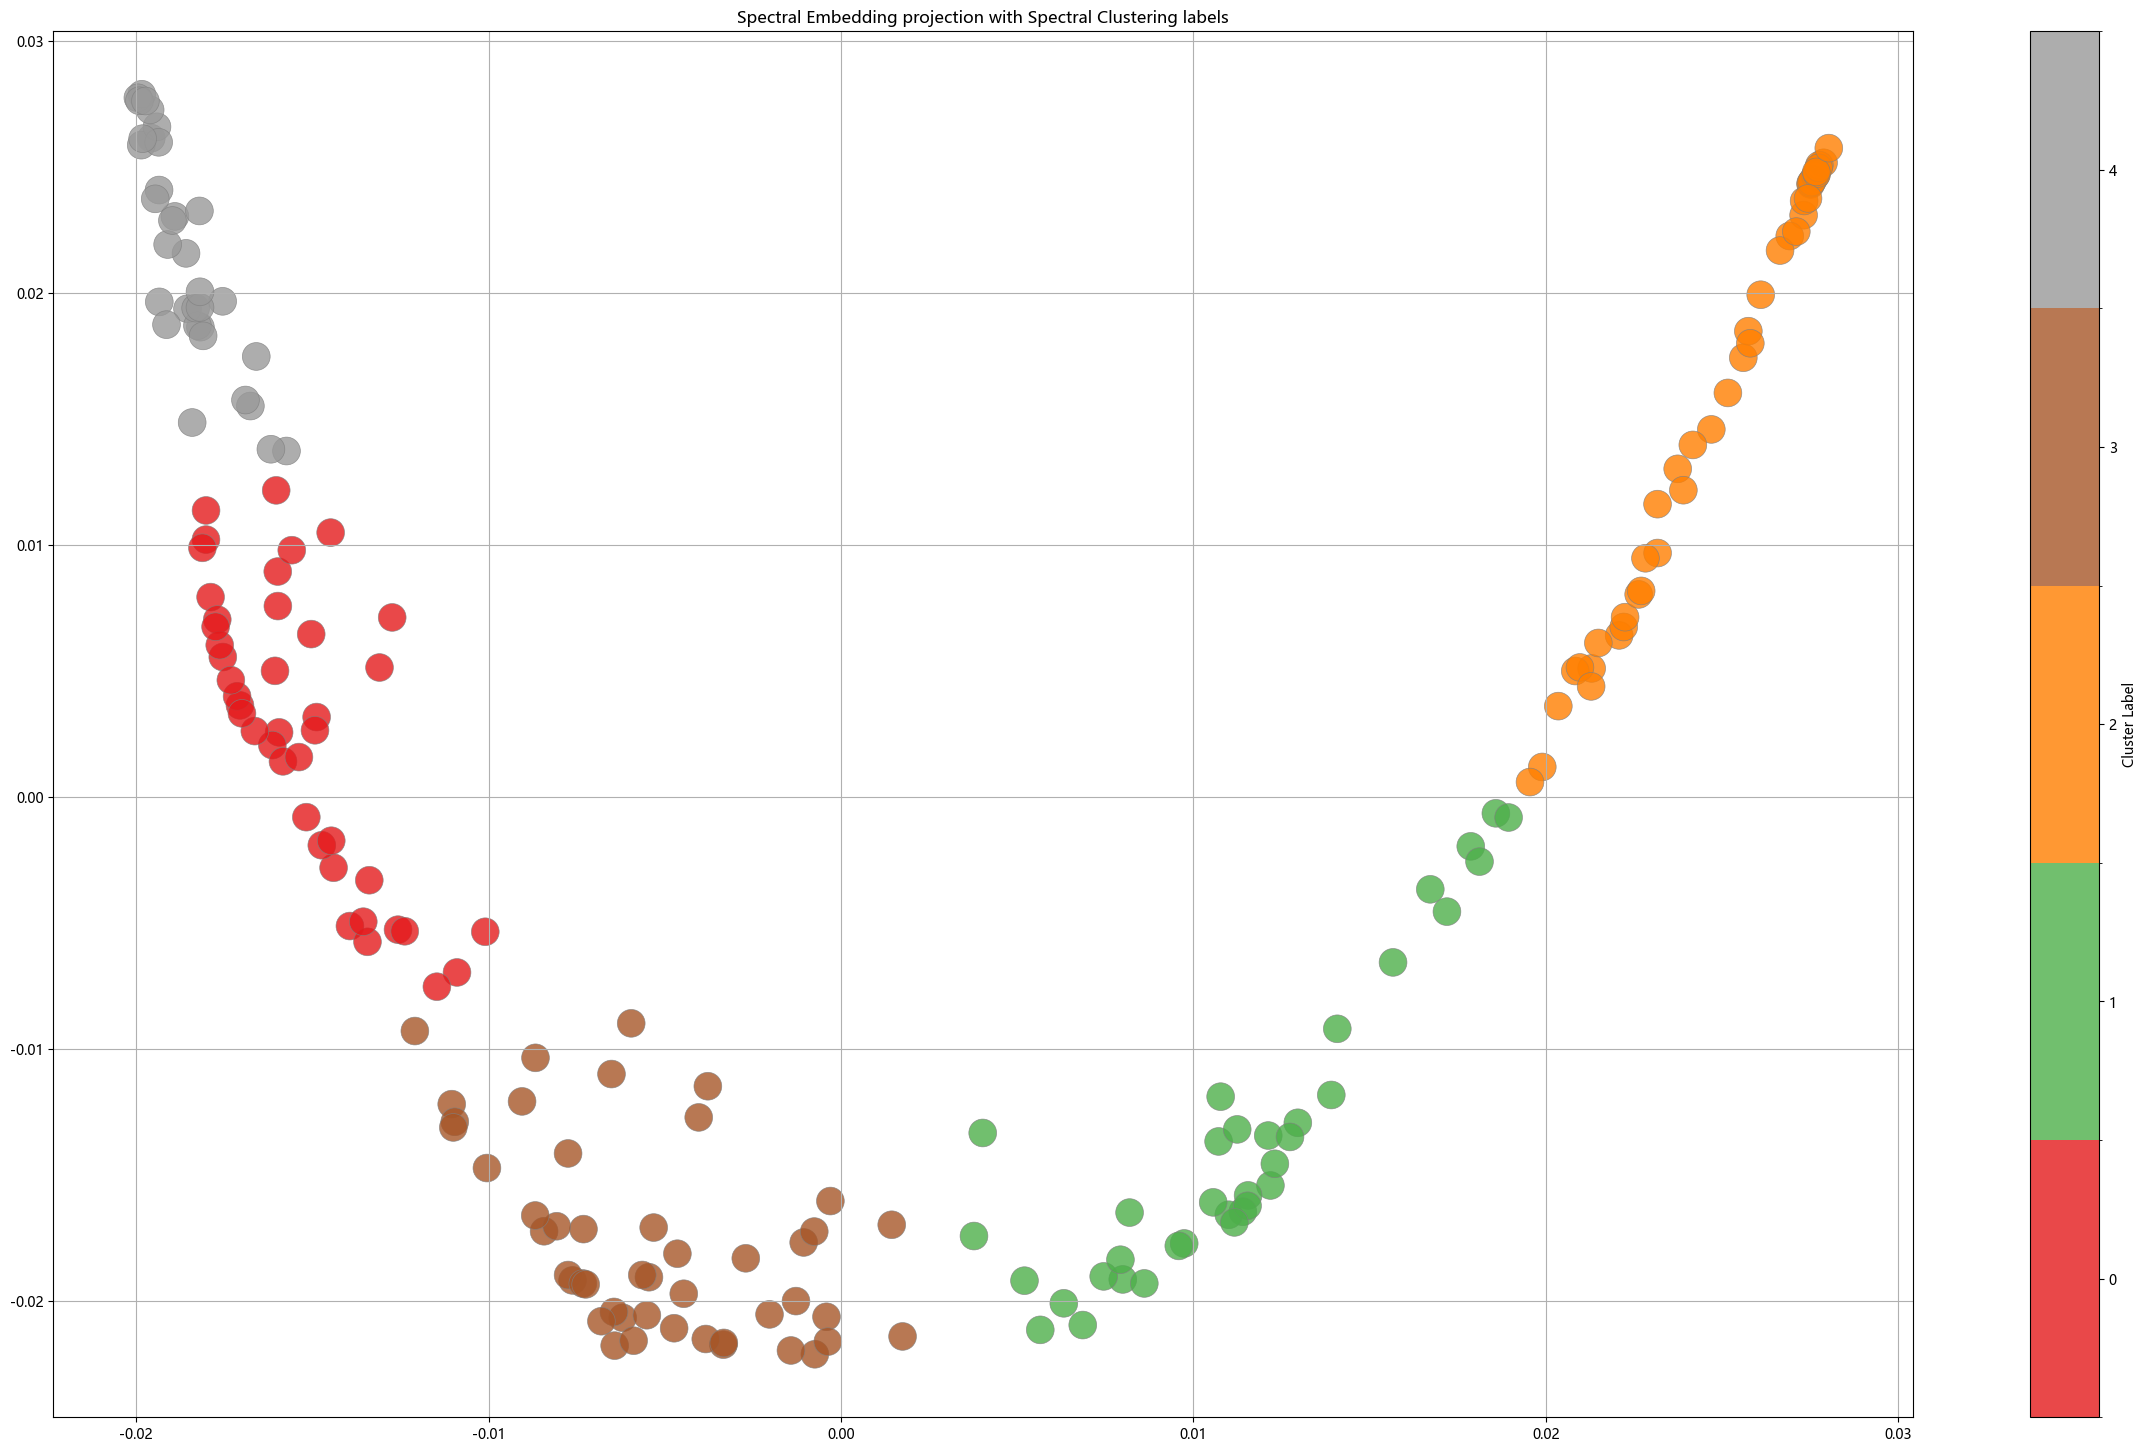

In [34]:
# 假设 labels 是 KMeans 聚类得到的 0~5 的整数
unique_labels = np.unique(labels)          # [0,1,2,3,4,5]
n_colors = len(unique_labels)               # 6

# 设置边界：每个整数 i 对应区间 [i-0.5, i+0.5]
bounds = np.arange(n_colors + 1) - 0.5      # [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

# 使用 BoundaryNorm，数据值落在哪个区间就用哪种颜色
norm = BoundaryNorm(bounds, plt.cm.Set1.N)  # 第二个参数是颜色数，直接使用 colormap 的颜色数

plt.figure(figsize=(30, 18))
plt.grid()
plt.scatter(digits_spec[:, 0], digits_spec[:, 1],
            c=labels, cmap='Set1', norm=norm,
            s=400, alpha=0.8, edgecolors='grey', linewidth=0.5)

# 创建颜色条，刻度设置为实际的标签值
cbar = plt.colorbar(ticks=unique_labels)
cbar.ax.set_yticklabels(unique_labels)       # 让刻度显示为 0,1,2,3,4,5
cbar.set_label('Cluster Label')

plt.title('Spectral Embedding projection with Spectral Clustering labels')
plt.show()

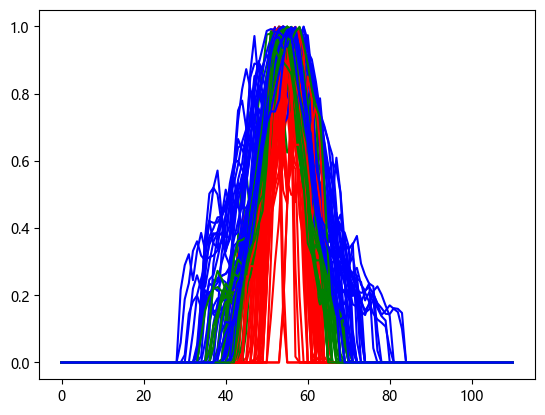

In [14]:
for i,((x, y), src, mol) in enumerate(zip(digits_spec, sources, molecules)):
    if mol=='SO2':
        if x<-0.01:
            plt.plot(flux_matrix[i],color='red')
        if -0.01<x<0.01:
            plt.plot(flux_matrix[i],color='green')
        if x>0.01:
            plt.plot(flux_matrix[i],color='blue')
            
# plt.ylim(0,0.2)


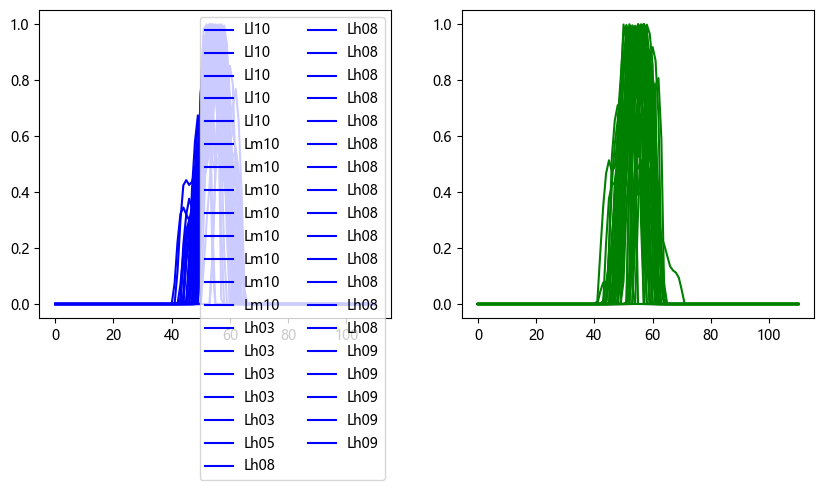

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
for i,((x, y), src, mol) in enumerate(zip(digits_spec, sources, molecules)):
    if -0.02<x<-0.01:
        if mol=='SO2':
            axes[0].plot(flux_matrix[i],color='blue',label=src)
        if mol!='SO2':
            axes[1].plot(flux_matrix[i],color='green')

axes[0].legend(ncol=2)
plt.show()

In [16]:
pca=PCA(n_components=2)
digits_pca=pca.fit_transform(flux_matrix)

tsne=TSNE(n_components=2,perplexity=min(30, len(fluxes)-1))
digits_tsne=tsne.fit_transform(flux_matrix)

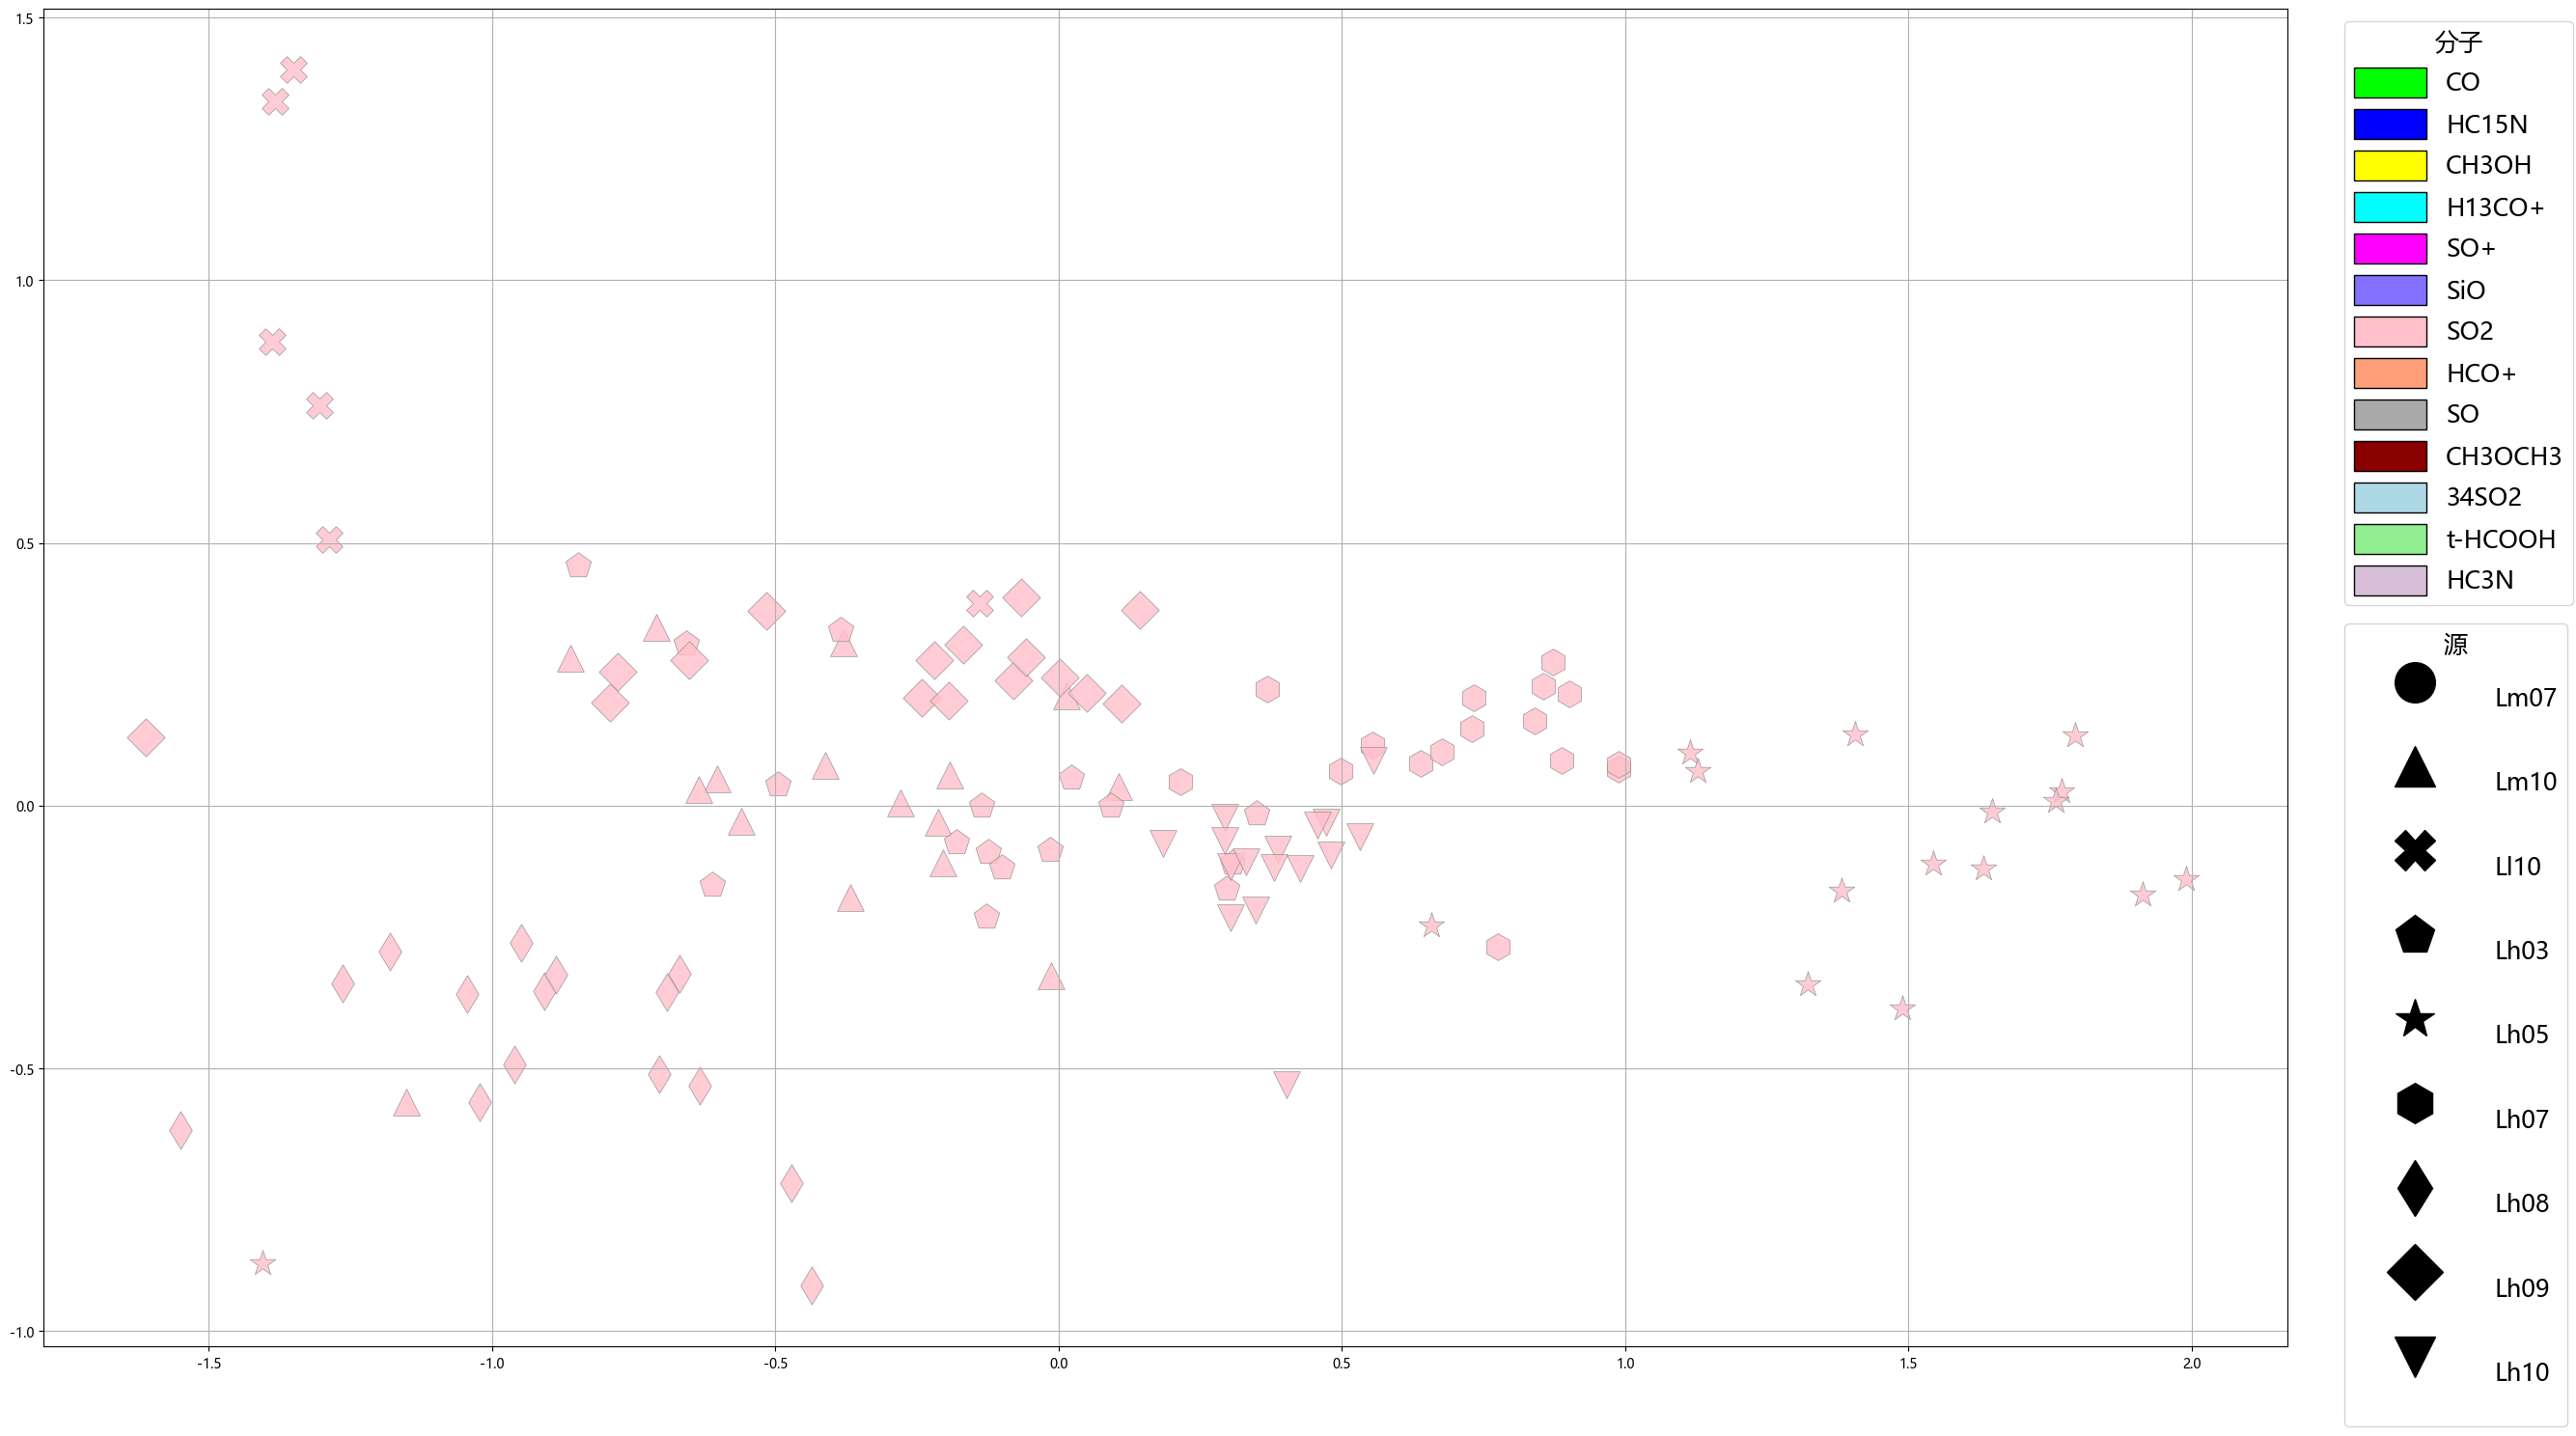

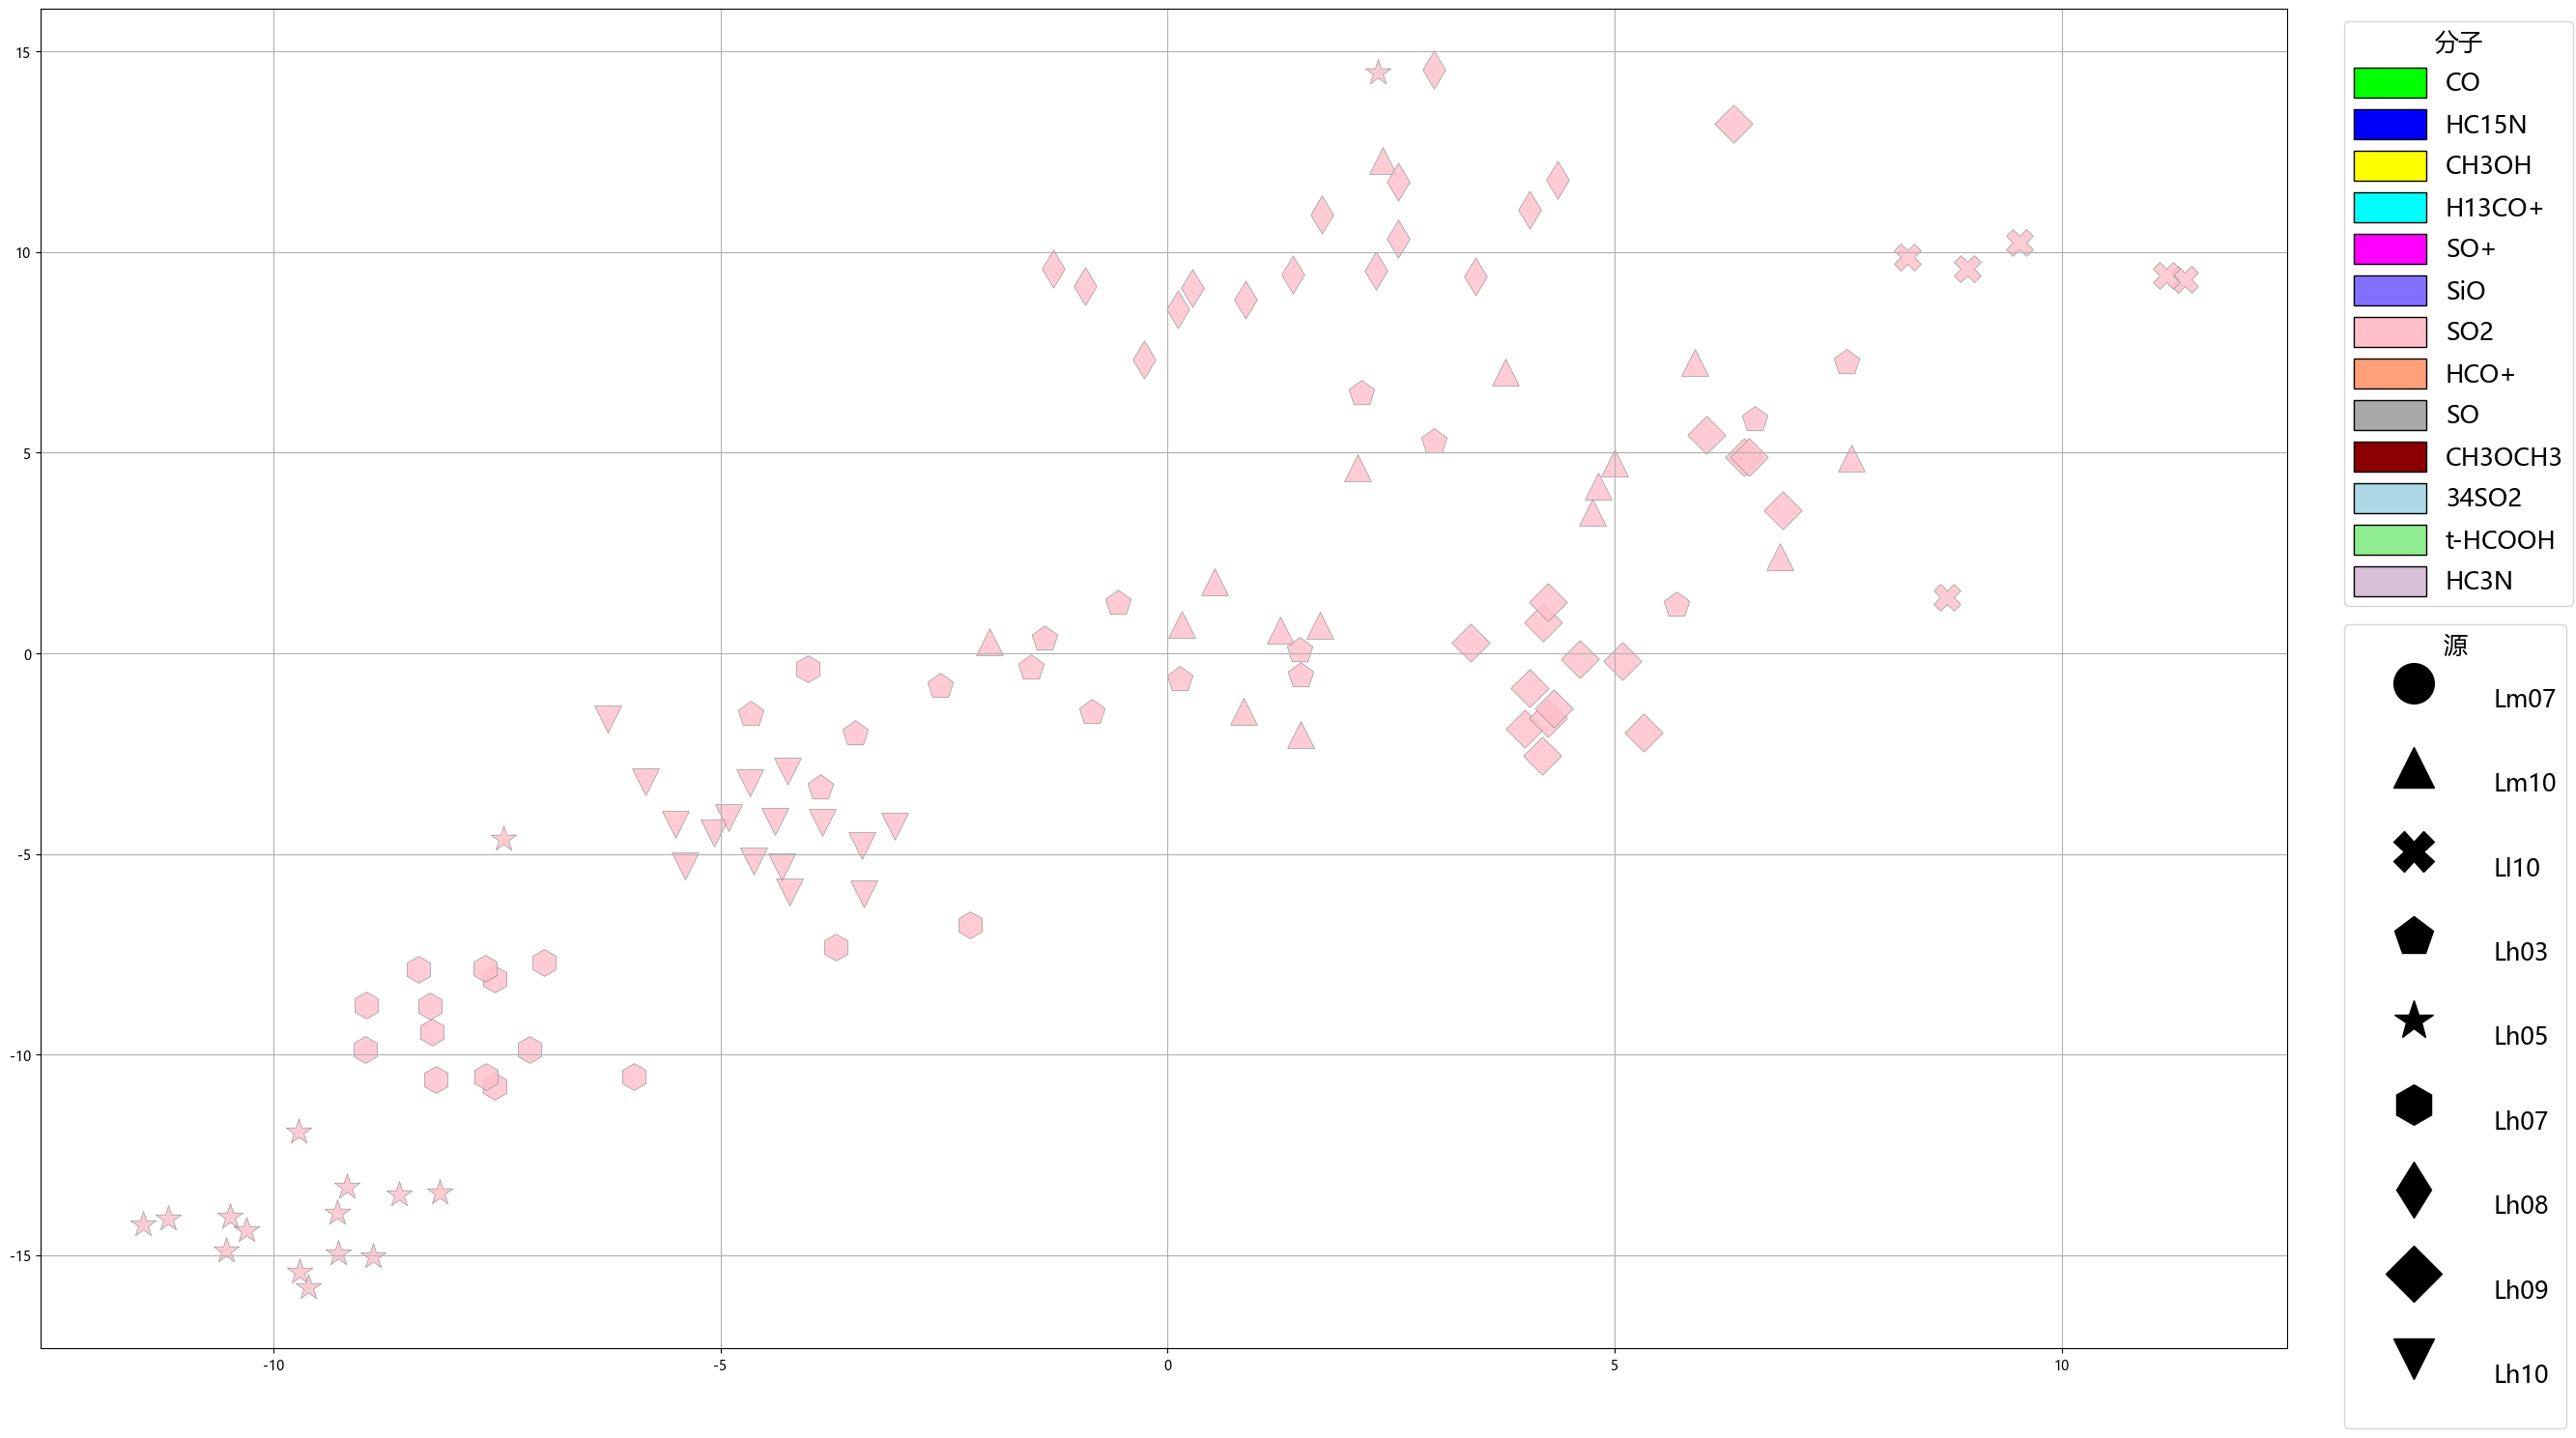

In [29]:
#--------------------pca-----------------------------
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()

# 绘制散点 - 修正点1：移除marker和c参数的中括号
for (x, y), src, mol in zip(digits_pca, sources, molecules):
    if mol=='SO2':
        color = color_map.get(mol, '#808080')  # 默认灰色
        marker = marker_map.get(src, 'o')  # 添加默认值
        # 注意：这里移除了marker=[marker]和c=[color]中的中括号
        plt.scatter(x, y, c=color, 
                    marker=marker, s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)

# 添加图例
legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
                    loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
                    handleheight=1.5, title_fontsize=18, fontsize=18)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_elements_src, title='源', 
                    loc='upper left', bbox_to_anchor=(1.02, 0.55), handlelength=5,
                    handleheight=5, title_fontsize=18, fontsize=18, 
                    labelspacing=0, markerscale=2.0)


#---------------------------tsne---------------------------------

fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()

# 绘制散点
for (x, y), src, mol in zip(digits_tsne, sources, molecules):
    if mol=='SO2':
        color = color_map.get(mol, '#808080')  # 默认灰色
        marker = marker_map.get(src, 'o')  # 添加默认值
        # 注意：这里移除了marker=[marker]和c=[color]中的中括号
        plt.scatter(x, y, c=color, marker=marker, s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)

# 添加图例
legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
                    loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
                    handleheight=1.5, title_fontsize=18, fontsize=18)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_elements_src, title='源', 
                    loc='upper left', bbox_to_anchor=(1.02, 0.55), handlelength=5,
                    handleheight=5, title_fontsize=18, fontsize=18, 
                    labelspacing=0, markerscale=2.0)

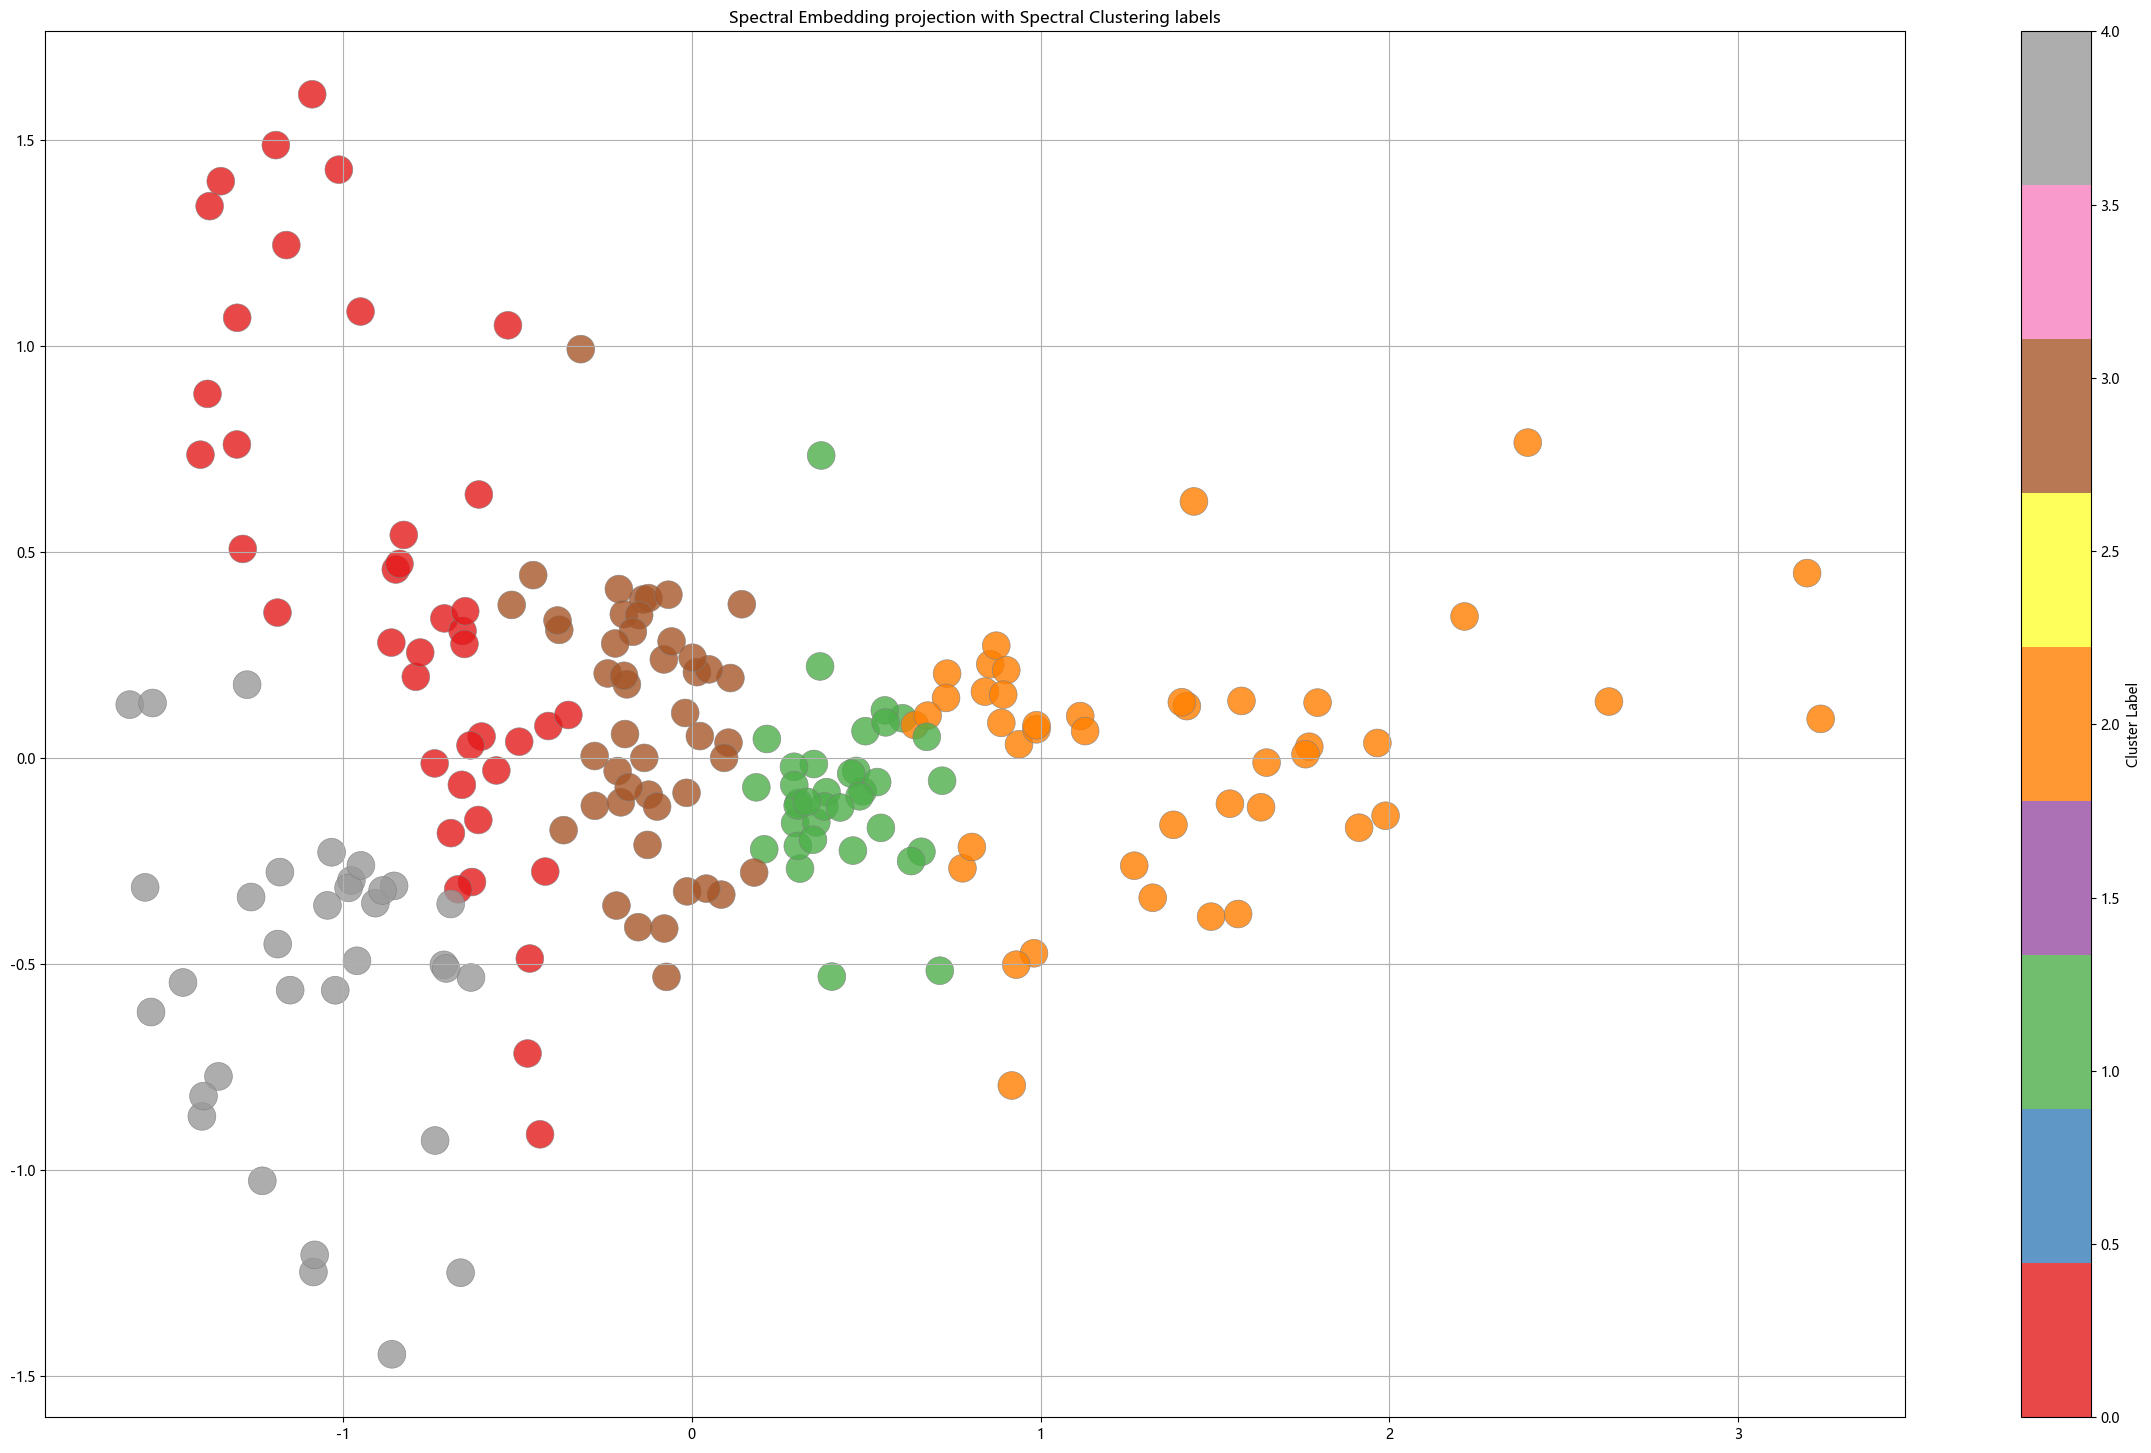

In [30]:
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()
plt.scatter(digits_pca[:, 0], digits_pca[:, 1], 
            c=labels, cmap='Set1',s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Spectral Embedding projection with Spectral Clustering labels')
plt.show()

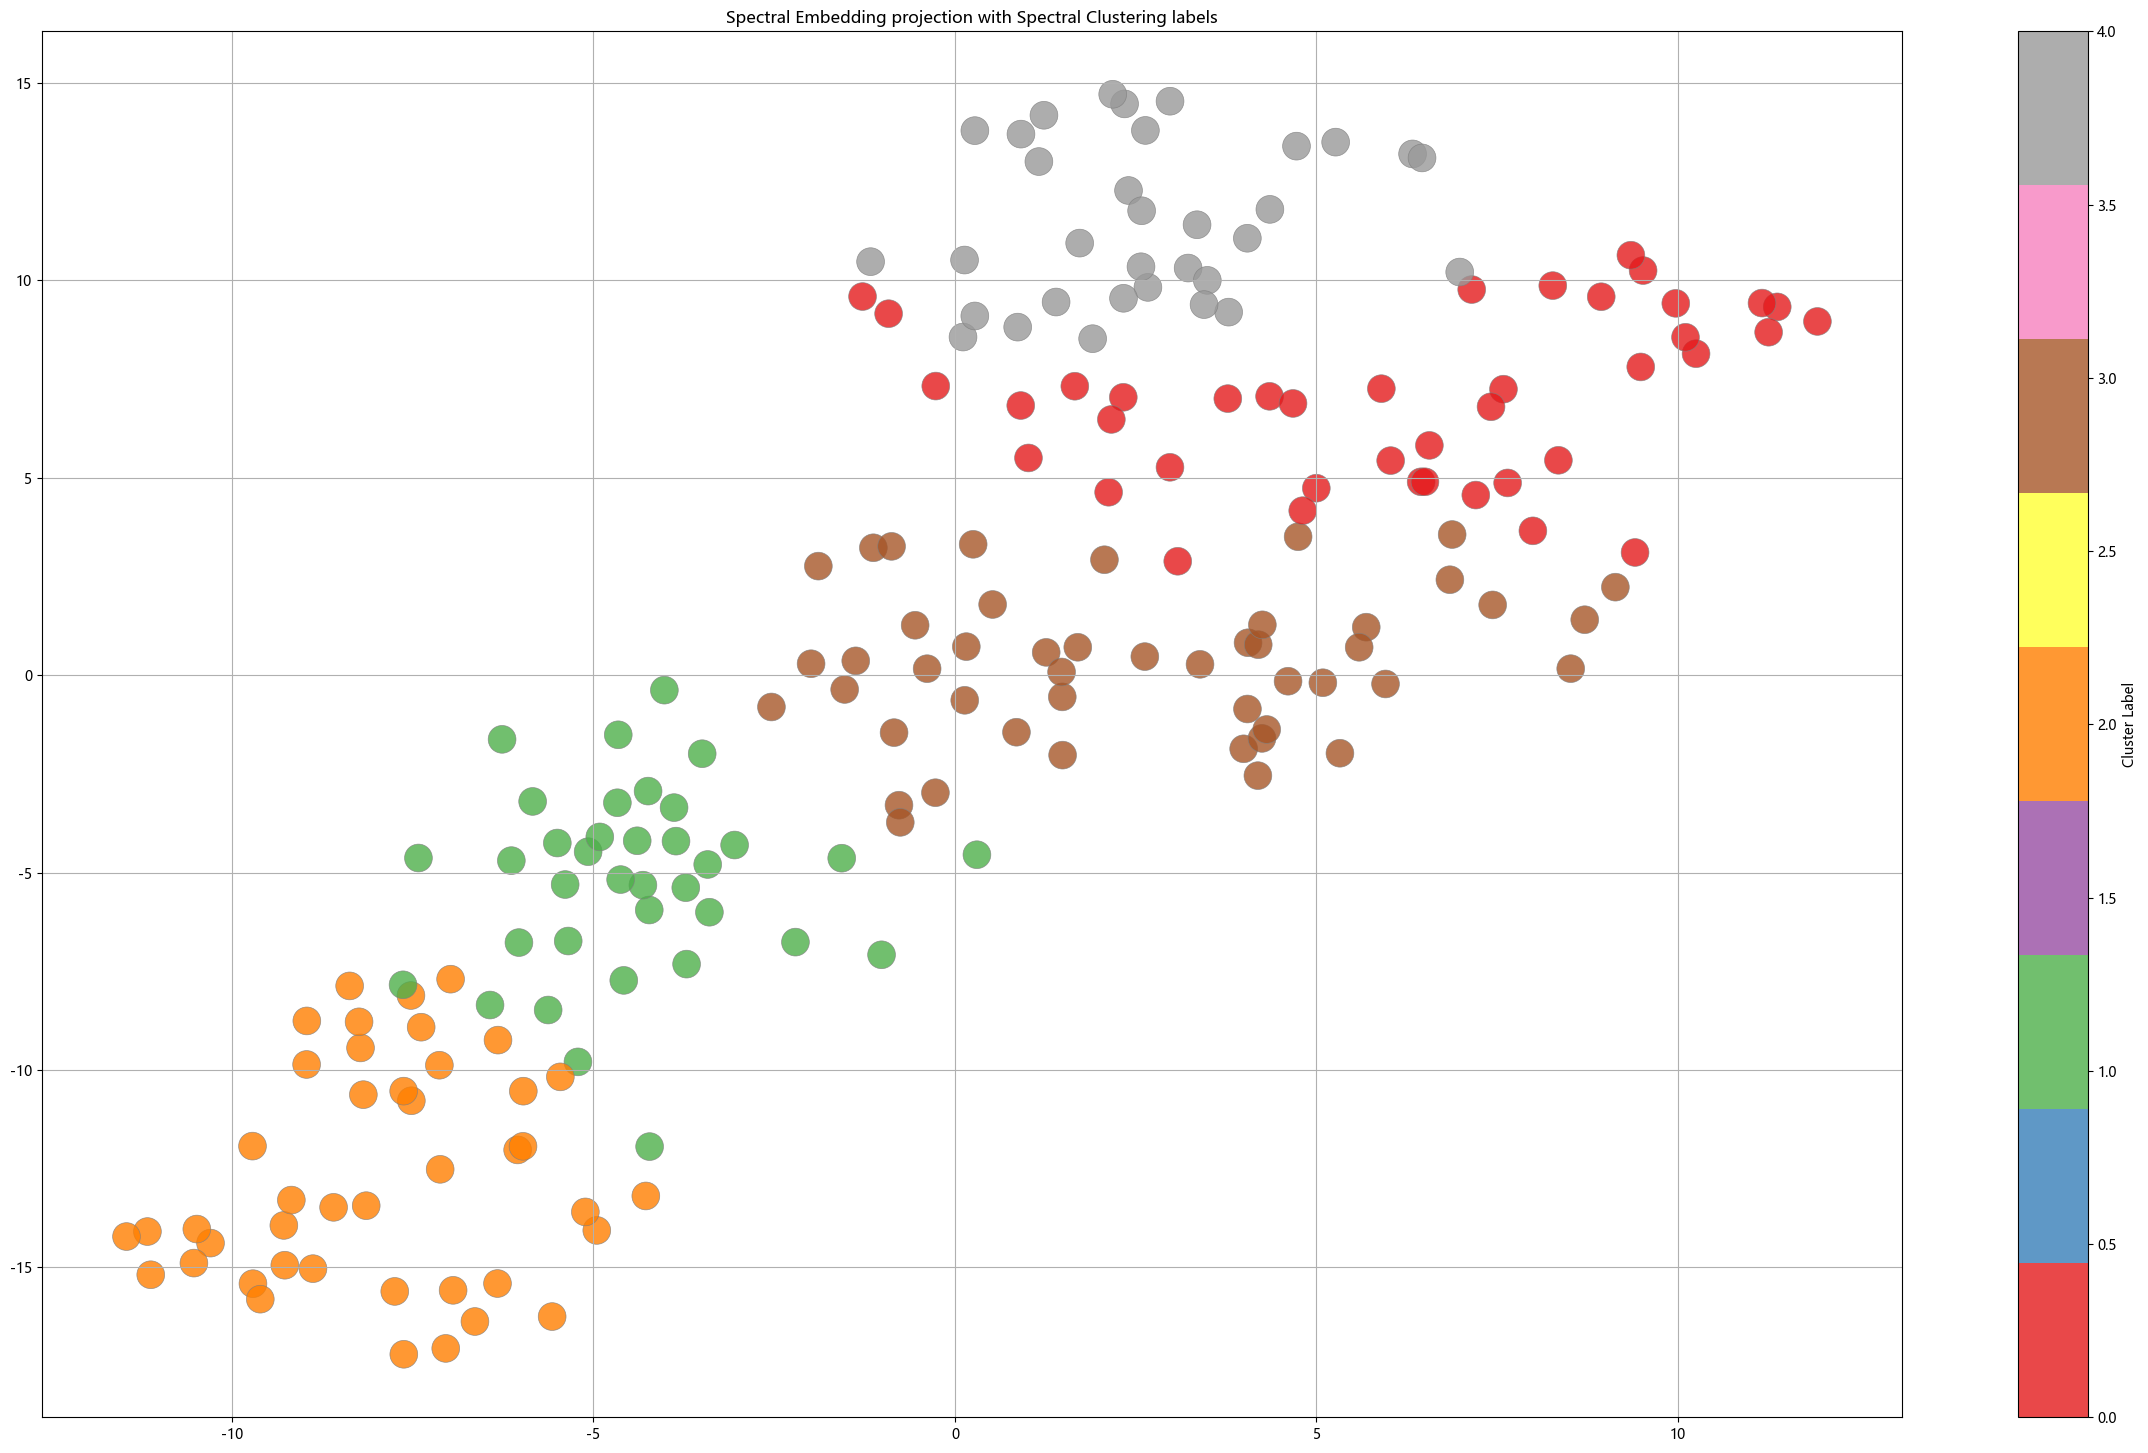

In [31]:
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()
plt.scatter(digits_tsne[:, 0], digits_tsne[:, 1], 
            c=labels, cmap='Set1',s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Spectral Embedding projection with Spectral Clustering labels')
plt.show()